# long generations num_generation ablation

some back of the envelope calcs for cost of these experiments

* old experiments (200 samples, 10 generations)
    * entailment predictions 2546
    * of those hashed 855 
    * total gpt-4 queries: 2546 - 855 = 1691
    * number of datapoints: 200
    * (queries for 400 datapoints: 3382)
    * total cost: 10
    * cost per prediction: 10/1691


* new epxeriments interim (400 samples (running still), 15 generations)
    * entailment predictions: 1179
    * of those hashed: 704
    * total gpt-4 queries:  1179 - 704 = 475
    * number of datapoints so far: 28
    * expected gpt-4 queries over 400 examples: 6785
    * expected total cost: 10/1691*6785 = 40


* cost on squad (still running, 15 generations)
    * entailment predictions: 29394
    * of those hashed: 5216
    * total gpt-4 queries: 24178
    * number of datapoints so far: 294
    * expected gpt-4 queries for 400 examples: 32895
    * expected total cost: 10/1691 * 32895 = 200



In [1]:
from IPython.display import display

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('..')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'goatml'

In [3]:
# export to eval file
def get_vals(x):
    return x['mean'], x['mean']-x['bootstrap']['std_err'], x['mean']+x['bootstrap']['std_err']
    # return x['mean'], x['bootstrap']['low'], x['bootstrap']['high']

def get_vals2(x):
    return x['means'], x['low'], x['high']


def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color, ax=ax)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color), ax=ax)
    ax.grid(axis='y', zorder=-10, alpha=0.3)

In [4]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

In [5]:
# # get wandb ids from runs
# runs_tmp = []

# # for run in [167201] + list(range(167209, 167213+1)) + list(range(167215, 167220+1)):
# # for run in range(167276, 167287+1):
# for run in range(167367, 167378+1):
#     wandb = !grep https log/*{run}*
#     wandb = wandb[1].split('/')[-1]
#     args = !grep Namespace log/*{run}*
#     args = args[0]
#     args = args[args.index('Args: Namespace(') + len('Args: Namespace('):-1]
#     args = {j.split('=')[0]: j.split('=')[1].replace("'", '') for j in args.split(', ')}
#     runs_tmp += [[run, wandb, int(args['use_num_generations']), args['eval_wandb_runid']]]
# sorted_tmp = [list(i) for i in list(pd.DataFrame(runs_tmp, columns=['slurmid', 'wandbid', 'num_generations', 'eval_wandb_id']).sort_values('num_generations').values)]
# print(sorted_tmp)
# {s[1]: f'bioasq-{s[2]}' for s in sorted_tmp}

In [6]:
# # get wandb ids for p_ik OOD RUNS
# runs_tmp = []

# to_ds = {
#     '1gxo9oef': 'trivia_qa',
#     'dqtye228': 'bioasq',
#     'uvfbxm6d': 'squad',
# }

# for run in range(168321, 168326+1):
#     wandb = !grep https log/*{run}*
#     wandb = wandb[1].split('/')[-1]
#     args = !grep Namespace log/*{run}*
#     args = args[0]
#     args = args[args.index('Args: Namespace(') + len('Args: Namespace('):-1]
#     args = {j.split('=')[0]: j.split('=')[1].replace("'", '') for j in args.split(', ')}
#     runs_tmp += [[run, wandb, args['eval_wandb_runid'], args['train_wandb_runid'], to_ds[args['eval_wandb_runid']], to_ds[args['train_wandb_runid']]]]
# sorted_tmp = [list(i) for i in list(pd.DataFrame(runs_tmp, columns=['slurmid', 'wandbid', 'eval_wandb_runid', 'train_wandb_runid', 'eval_dataset', 'train_dataset']).values)]
# sorted_tmp

Take runs at 8 generations and re-run entailment calculation with gpt-3.5 and gpt-4 turbo

Just take config from these runs


```
    '37it7nr9': 'trivia_qa-8',
    '3d6obogq': 'bioasq-8', --> restrict to 200
    '8ehbkd99': 'squad-8',
```

And re-run, but with different entailment model.

```
extra_cfg1="--entailment_model=gpt-3.5 --no-use_all_generations --use_num_generations=8"
sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=1gxo9oef --num_eval_samples=400 $extra_cfg1
sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=dqtye228 --num_eval_samples=200 $extra_cfg1
sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=uvfbxm6d --num_eval_samples=400 $extra_cfg1

extra_cfg2="--entailment_model=gpt-4-turbo --no-use_all_generations --use_num_generations=8"
sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=1gxo9oef --num_eval_samples=400 $extra_cfg2
sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=dqtye228 --num_eval_samples=200 $extra_cfg2
sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=uvfbxm6d --num_eval_samples=400 $extra_cfg2

168315 -- 168320
```


NOW the p_ik OOD EVALS!

```
sbatch slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --no-compute_predictive_entropy --eval_wandb_runid=1gxo9oef --num_eval_samples=400 --train_wandb_runid=dqtye228
sbatch slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --no-compute_predictive_entropy --eval_wandb_runid=1gxo9oef --num_eval_samples=400 --train_wandb_runid=uvfbxm6d

sbatch slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --no-compute_predictive_entropy --eval_wandb_runid=dqtye228 --num_eval_samples=200 --train_wandb_runid=1gxo9oef
sbatch slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --no-compute_predictive_entropy --eval_wandb_runid=dqtye228 --num_eval_samples=200 --train_wandb_runid=uvfbxm6d

sbatch slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --no-compute_predictive_entropy --eval_wandb_runid=uvfbxm6d --num_eval_samples=400 --train_wandb_runid=1gxo9oef
sbatch slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --no-compute_predictive_entropy --eval_wandb_runid=uvfbxm6d --num_eval_samples=400 --train_wandb_runid=dqtye228

168321 -- 168326

```




In [7]:
# The new runs are doing strict entailment _and_ condition on question,
runs = {
# 167019 / 1gxo9oef --> original generate_answers run trivia-qa
# 167127 / 1sn9kt0u --> compute uncertainties trivia-qa
# 167194 / ceumvx4j --> final analyze run
# --> ablation 3 -- 15: 167201, 167209 -- 167213, 167215--167220
    'ceumvx4j': 'trivia_qa-15',
    'kyps0l5c': 'trivia_qa-3',
    'lmgl9uqw': 'trivia_qa-4',
    'h907rs39': 'trivia_qa-5',
    '4c75wp2w': 'trivia_qa-6',
    'w9s4glzs': 'trivia_qa-7',
    '37it7nr9': 'trivia_qa-8',
    'acf22lqm': 'trivia_qa-9',
    'rfud6pex': 'trivia_qa-10',
    'wlzopa8b': 'trivia_qa-11',
    'ko4lthz7': 'trivia_qa-12',
    'm2pey1cf': 'trivia_qa-13',
    'ozwofq1z': 'trivia_qa-14',

# 167018 / dqtye228 --> original generate_answers run bioasq
# 167272 / i855qzau --> compute uncertainties bioasq ---> restrict to 200 generations because of cost. push comes to shove, can re-run again.
# 167327 / m9c2ipfs --> final analyze run
# ablation 3 -- 5: 167367 -- 167378
    'm9c2ipfs': 'bioasq-15',
    'zu0gvsvv': 'bioasq-3',
    'penhh9on': 'bioasq-4',
    '7s5gabz4': 'bioasq-5',
    'eogcnegj': 'bioasq-6',
    'nhog7yk5': 'bioasq-7',
    '3d6obogq': 'bioasq-8',
    '9n1pxwse': 'bioasq-9',
    '93z4l6jz': 'bioasq-10',
    'c9cg7ocd': 'bioasq-11',
    's1dozf1c': 'bioasq-12',
    'zldi7tma': 'bioasq-13',
    'd88w9ul1': 'bioasq-14',

# 167020 / uvfbxm6d --> original generate_answers run squad
# 167178 / uh7pp7iu --> compute uncertainties squad
# 167275 / 0tit46iz --> final analyze run

# ablation 3--15: 167276, 167277 -- 167287
    '0tit46iz': 'squad-15',
    '0b9ugqc6': 'squad-3',
    '2k3n5vwu': 'squad-4',
    'wmuerxk7': 'squad-5',
    '28q6db61': 'squad-6',
    'fsbt6khu': 'squad-7',
    '8ehbkd99': 'squad-8',
    'v1i8nxv1': 'squad-9',
    'f8lk2529': 'squad-10',
    'y30wx2tv': 'squad-11',
    'y46ezmtv': 'squad-12',
    '5f47uiac': 'squad-13',
    '4m9htci6': 'squad-14',
}
# runs at other num_generations --> launch only after initial compute_uncertainties is run



# }

all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


In [8]:
get_cfg = lambda dictionary: {k: v['value'] for k, v in dictionary.items() if isinstance(v, dict) and k != '_wandb'}
def get_diff(xk, yk, configs=all_configs, runs=runs):

    x, y = configs[xk], configs[yk]
    print(50*' ' + f'{runs[xk]:<20} {runs[yk]}')
    diffs = set(get_cfg(x).items()) ^ set(get_cfg(y).items())
    diffs = set([k for k, _ in diffs])
    for k in diffs:
        print(f'{k:<50} {get_cfg(x).get(k, "missing"):<20} {get_cfg(y).get(k, "missing")}')
    print(80 * '-')

# get_diff('kyps0l5c', 'lmgl9uqw')
get_diff('8ehbkd99', '5f47uiac')

                                                  squad-8              squad-13
p_true_num_fewshot                                 7                    3
use_num_generations                                8                    13
--------------------------------------------------------------------------------


In [9]:
p_ik_runs = {
    'sd3ihole': 'trivia_qa-bioasq',
    'lcobj81w': 'trivia_qa-squad',
    'jxr5kvnm': 'bioasq-trivia_qa',
    'b857ibdw': 'bioasq-squad',
    'wtp516v5': 'squad-trivia_qa',
    'g56g0fxh': 'squad-bioasq',
}
p_ik_configs, p_ik_results = {}, {}

for wandb_id in p_ik_runs:
    p_ik_results[wandb_id], p_ik_configs[wandb_id] = restore_file(wandb_id)


In [10]:
get_diff('sd3ihole', 'lcobj81w', configs=p_ik_configs, runs=p_ik_runs)
get_diff('sd3ihole', 'jxr5kvnm', configs=p_ik_configs, runs=p_ik_runs)

                                                  trivia_qa-bioasq     trivia_qa-squad
train_wandb_runid                                  dqtye228             uvfbxm6d
ood_training_set                                   bioasq               squad
--------------------------------------------------------------------------------
                                                  trivia_qa-bioasq     bioasq-trivia_qa
use_context                                        0                    True
dataset                                            trivia_qa            bioasq
train_wandb_runid                                  dqtye228             1gxo9oef
ood_training_set                                   bioasq               trivia_qa
p_true_num_fewshot                                 5                    2
num_eval_samples                                   400                  200
eval_wandb_runid                                   1gxo9oef             dqtye228
-----------------------------------

Can we improve accuracy by instead voting the answer from the (high-temperature) clusters?

In [11]:
# for wandb_id, run_name in runs.items():
#     config = all_configs[wandb_id]
#     results = all_results[wandb_id]

#     df = get_perfs(results)
#     plot_bar(df)
#     plt.gca().set_title(run_name)
#     plt.gca().grid()
#     plt.gca().set_ylim(0, 1)


model,bioasq,squad,trivia_qa
dataset,,,
10,0.545,0.3475,0.8675
11,0.545,0.3475,0.8675
12,0.545,0.3475,0.8675
13,0.545,0.3475,0.8675
14,0.545,0.3475,0.8675
15,0.545,0.3475,0.8675
3,0.545,0.3475,0.8675
4,0.545,0.3475,0.8675
5,0.545,0.3475,0.8675


Text(0, 0.5, 'accuracy')

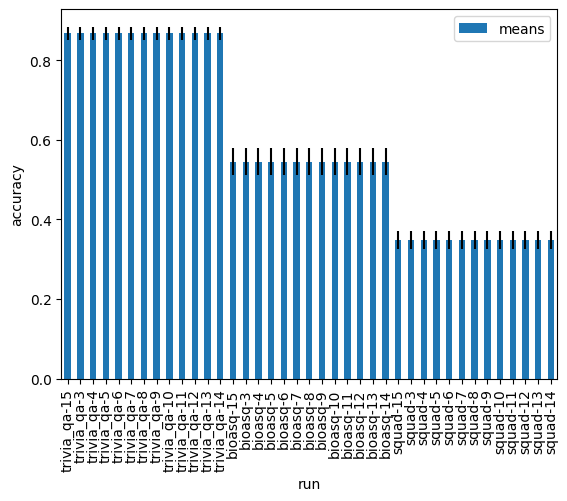

In [12]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())
    
    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandb_id'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandb_id'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)
all_runs['num_generations'] = all_runs.run.map(lambda x: int(x.split('-')[1]))
all_runs['dataset'] = all_runs.run.map(lambda x: x.split('-')[0])

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run'))
plt.gca().set_ylabel('accuracy')

In [13]:
pik_perfdf, pik_pdfs, pik_all_runs = get_perf_df(p_ik_runs, all_results=p_ik_results)
pik_all_runs = pik_all_runs.set_index('method').loc['p_ik'].reset_index()
pik_all_runs['eval_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[0])
pik_all_runs['train_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[1])

model,bioasq,squad,trivia_qa
dataset,,,
bioasq,NaN,0.3475,0.8675
squad,0.545,NaN,0.8675
trivia_qa,0.545,0.3475,NaN


* 7b largely performs very similar to 70b, usually a little worse (5-10%)
* Only big difference is for trivia-qa, where removing context leads to ~20 percent accuracy hit from ~85 to ~65 (this is not necessarily bad for us though)


In [14]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)


Text(0.5, 80.7222222222222, 'Number of generations')

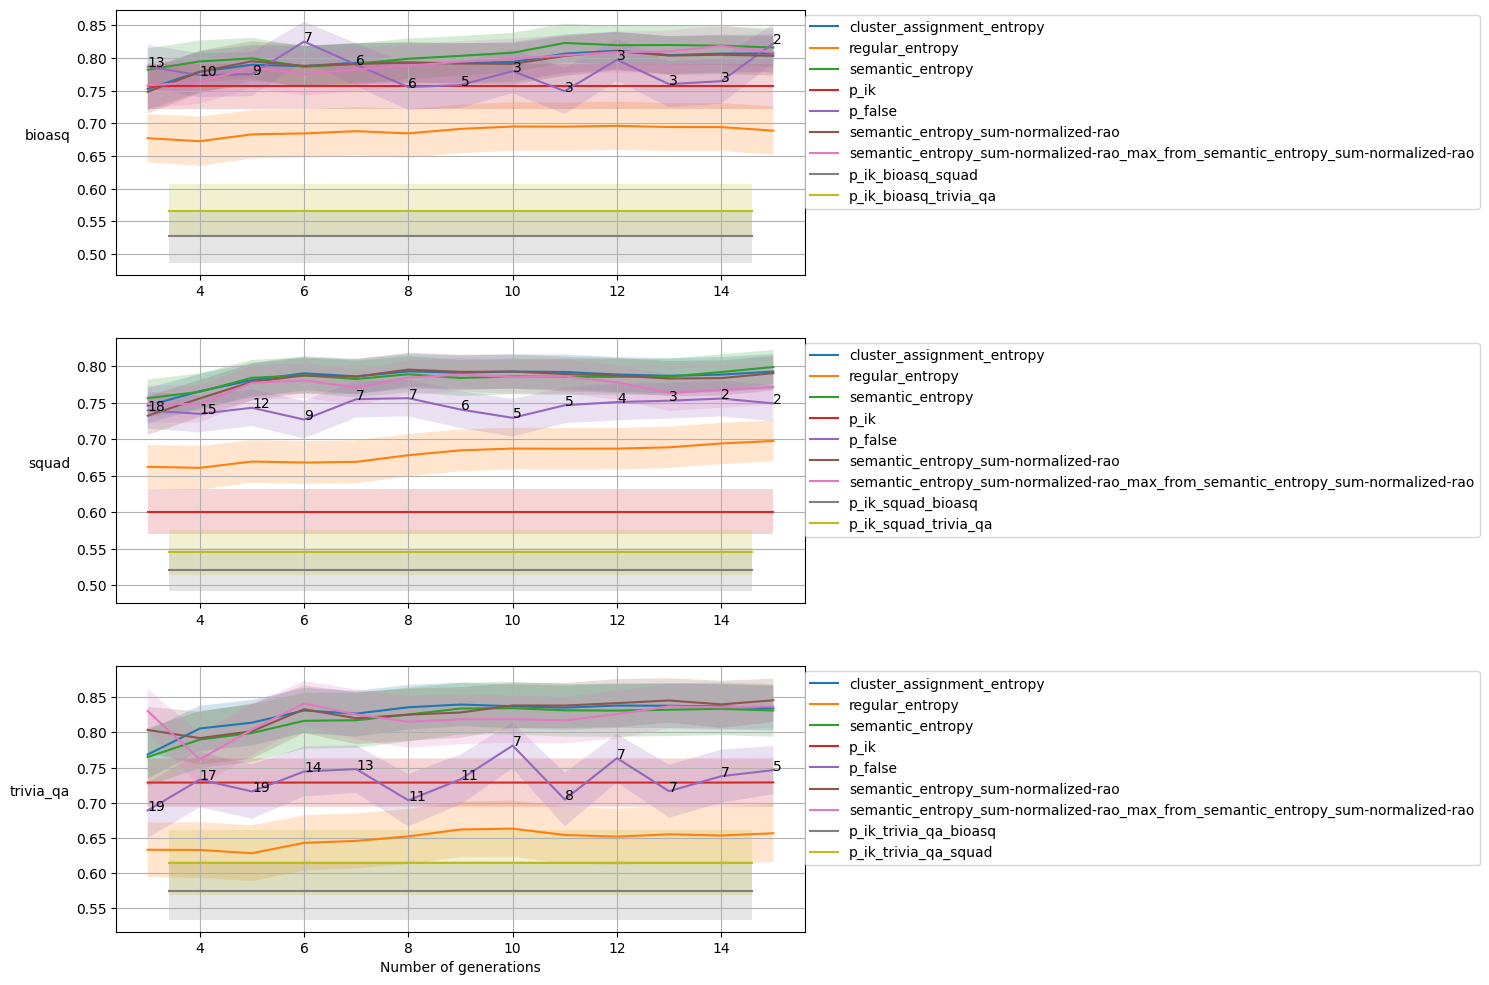

In [15]:
metric = 'AUROC'

df2 = deepcopy(all_runs)
df2 = df2[df2.metric == metric]
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']

fig, axes = plt.subplots(df2.dataset.nunique(), figsize=(15, 10))

if df2.dataset.nunique() == 1:
    axes = [axes]

methods = main_methods

for ax, (dataset, gdf) in  zip(axes, df2.groupby('dataset')):
    ax.set_ylabel(dataset, rotation=0, ha='right')
    ax.grid()
    for m, method in enumerate(methods):
        df3 = gdf[gdf.method == method]
        x, y, h, l = df3.num_generations.values, df3.means.values, df3.low.values, df3.high.values
        idxs = np.argsort(x)
        x, y, h, l = x[idxs], y[idxs], h[idxs], l[idxs]
        ax.plot(x, y, label=method)
        ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
        if method == 'p_false':
            ids = df3.wandb_id.values[idxs]
            if dataset == 'squad':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            elif dataset == 'trivia_qa':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 5})['value'] for wid in ids]
            elif dataset == 'bioasq':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            else:
                raise
            for xpos, ypos, text in zip(x, y, num_p_true):
                ax.text(xpos, ypos, text)

    xlims = ax.get_xlim()
    x = [xlims[0]+1, xlims[1]-1]
    for train_dataset, pik_tmp in pik_all_runs.set_index('metric').loc[metric].set_index('eval_dataset').loc[dataset].groupby('train_dataset'):
        m, l, h = get_vals2(pik_tmp.iloc[0])
        ax.plot(x, [m, m], label=f'p_ik_{dataset}_{train_dataset}')
        ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
    ax.set_xlim(*xlims)

    ax.legend(loc=(1, 0.25))

print("text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)")
plt.tight_layout()
axes[-1].set_xlabel('Number of generations')

# Add gpt3/gpt4turbo results (use this for entailment calculation!)

In [16]:
gpt_runs = {
    'jj5da8bd': 'bioasq-gpt3.5',
    'mpgj9mz3': 'trivia_qa-gpt3.5',
    '5bqecpaq': 'squad-gpt3.5',
    'rvwyfqfy': 'bioasq-gpt4t',
    'ogqt6jkk': 'squad-gpt4t',
    '64apxuf6': 'trivia_qa-gpt4t',

}
gpt_configs, gpt_results = {}, {}

for wandb_id in gpt_runs:
    gpt_results[wandb_id], gpt_configs[wandb_id] = restore_file(wandb_id)

gpt_perfdf, gpt_pdfs, gpt_all_runs = get_perf_df(gpt_runs, gpt_results)
gpt_all_runs['model'] = gpt_all_runs.run.map(lambda x: x.split('-')[1])
gpt_all_runs['dataset'] = gpt_all_runs.run.map(lambda x: x.split('-')[0])

model,bioasq,squad,trivia_qa
dataset,,,
gpt3.5,0.545,0.3475,0.8675
gpt4t,0.545,0.3475,0.8675


-0.2
0.0
0.2
-0.2
0.0
0.2
-0.2
0.0
0.2
text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)


Text(0.5, 190.7222222222222, 'Number of generations')

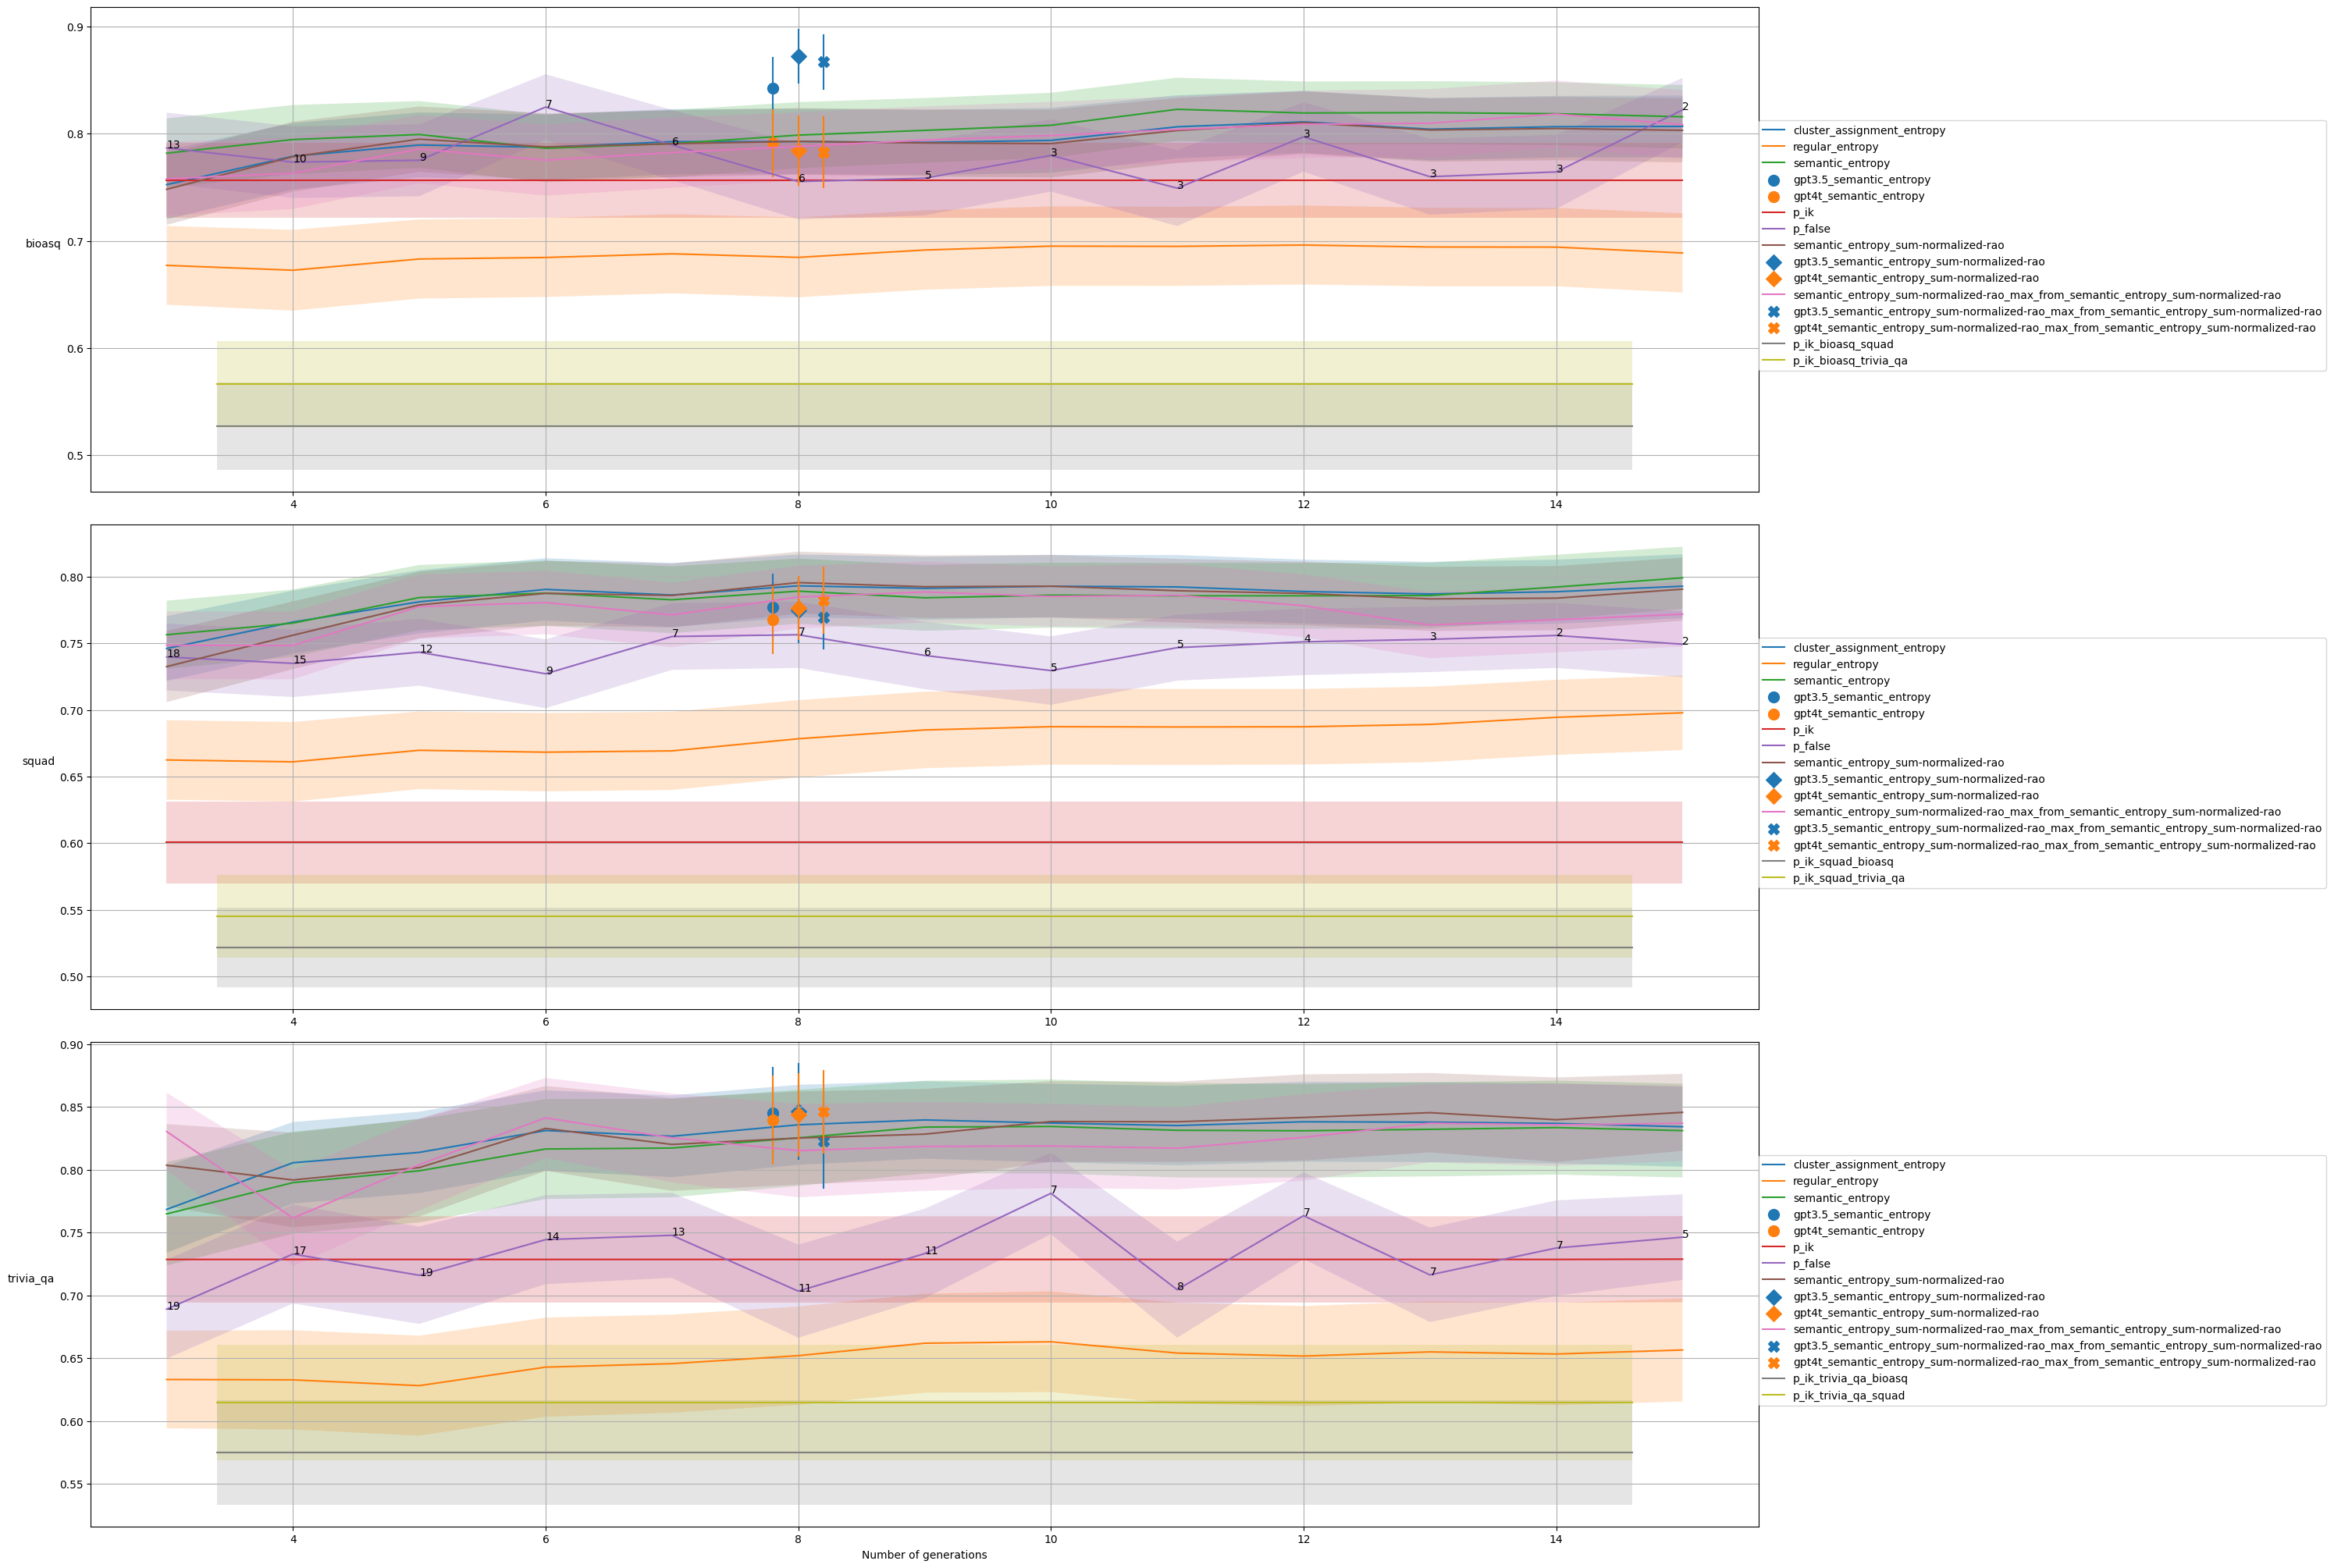

In [17]:
metric = 'AUROC'

df2 = deepcopy(all_runs)
df2 = df2[df2.metric == metric]
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']

fig, axes = plt.subplots(df2.dataset.nunique(), figsize=(30, 20))

if df2.dataset.nunique() == 1:
    axes = [axes]

methods = main_methods
sem_methods = ['semantic_entropy', 'semantic_entropy_sum-normalized-rao', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']


for ax, (dataset, gdf) in  zip(axes, df2.groupby('dataset')):
    ax.set_ylabel(dataset, rotation=0, ha='right')
    ax.grid()
    for m, method in enumerate(methods):
        df3 = gdf[gdf.method == method]
        x, y, h, l = df3.num_generations.values, df3.means.values, df3.low.values, df3.high.values
        idxs = np.argsort(x)
        x, y, h, l = x[idxs], y[idxs], h[idxs], l[idxs]
        ax.plot(x, y, label=method)
        ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
        if method == 'p_false':
            ids = df3.wandb_id.values[idxs]
            if dataset == 'squad':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            elif dataset == 'trivia_qa':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 5})['value'] for wid in ids]
            elif dataset == 'bioasq':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            else:
                raise
            for xpos, ypos, text in zip(x, y, num_p_true):
                ax.text(xpos, ypos, text)
    
        if method in sem_methods:
            # skip for those methods b/c they do not depend on entailment
            tmp = gpt_all_runs.set_index('metric').loc[metric].set_index('dataset').loc[dataset].set_index('method').loc[method]
            jitter = (-1 + list(range(3))[sem_methods.index(method)])/5
            print(jitter)
            for i, (model, model_df) in enumerate(tmp.groupby('model')):
                x = gpt_configs[model_df.wandb_id.values[0]]['use_num_generations']['value']
                m, l, h = get_vals2(model_df.iloc[0])
                ax.scatter([x+jitter], [m], label=f'{model_df.model.values[0]}_{method}', c=f'C{i}', marker=['o', 'D', 'X'][sem_methods.index(method)], s=100)
                ax.plot([x+jitter, x+jitter], [l, h], c=f'C{i}')

    # plot p_ik_OOD
    xlims = ax.get_xlim()
    x = [xlims[0]+1, xlims[1]-1]
    for train_dataset, pik_tmp in pik_all_runs.set_index('metric').loc[metric].set_index('eval_dataset').loc[dataset].groupby('train_dataset'):
        m, l, h = get_vals2(pik_tmp.iloc[0])
        ax.plot(x, [m, m], label=f'p_ik_{dataset}_{train_dataset}')
        ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
    ax.set_xlim(*xlims)

    ax.legend(loc=(1, 0.25))

print("text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)")
plt.tight_layout()
axes[-1].set_xlabel('Number of generations')

# Rerun with gpt35 accuracy checking

Base config on these runs, but change entailment model to latest gpt35 model
````
bioasq 3d6obogq        
trivia_qa 37it7nr9     
squad 8ehbkd99         

sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --recompute_accuracy --metric=llm_gpt-3.5 --use_num_generations=8 --entailment_model=gpt-3.5 --no-use_all_generations --entailment_cache_only --eval_wandb_runid=dqtye228 --entailment_cache_id=goatml/semantic_uncertainty/jj5da8bd --num_eval_samples=200

sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --recompute_accuracy --metric=llm_gpt-3.5 --use_num_generations=8 --entailment_model=gpt-3.5 --no-use_all_generations --entailment_cache_only --eval_wandb_runid=1sn9kt0u --entailment_cache_id=goatml/semantic_uncertainty/mpgj9mz3

sbatch --nodelist=oat3 --dependency=singleton  --job-name=A slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --recompute_accuracy --metric=llm_gpt-3.5 --use_num_generations=8 --entailment_model=gpt-3.5 --no-use_all_generations --entailment_cache_only --eval_wandb_runid=uvfbxm6d --entailment_cache_id=goatml/semantic_uncertainty/5bqecpaq


169502--169504
```

In [18]:
acc_runs = {
    'nu83s9tf': 'bioasq-acc_gpt35',
    'm3y3x605': 'squad-acc_gpt35',
    'lgurwdvq': 'trivia_qa-acc_gpt35',
}
acc_configs, acc_results = {}, {}

for wandb_id in acc_runs:
    acc_results[wandb_id], acc_configs[wandb_id] = restore_file(wandb_id)

acc_perfdf, acc_pdfs, acc_all_runs = get_perf_df(acc_runs, acc_results)
acc_all_runs['model'] = acc_all_runs.run.map(lambda x: x.split('-')[1])
acc_all_runs['dataset'] = acc_all_runs.run.map(lambda x: x.split('-')[0])

# this run uses gpt-35 to judge the accuracy, and gpt35 to compute entailment!

model,bioasq,squad,trivia_qa
dataset,,,
acc_gpt35,0.615,0.4325,0.8725


In [19]:
# this run uses llama-2 to judge the accuracy, and gpt35/gpt4t to compute entailment
gpt_perfdf.set_index('method').loc['accuracy'].set_index('run')

,means,low,high
run,,,
bioasq-gpt3.5,0.5450,0.510364,0.579636
trivia_qa-gpt3.5,0.8675,0.851013,0.883987
squad-gpt3.5,0.3475,0.324747,0.370253
bioasq-gpt4t,0.5450,0.510364,0.579636
squad-gpt4t,0.3475,0.324747,0.370253
trivia_qa-gpt4t,0.8675,0.851013,0.883987


**It looks like there are significant differences here!**

In [20]:
# PLAN:
# let's just take a look at the aurocs first --> hmm... unfortunately this does not look too grat


# then let's take a look at some predictions of gpt-35 manually to make sure they don't suck
# seee 2023-11-16-accuracy_metric_comparison_gpt35_llama-2

# do a re-run start to finish of these to make sure they are representative

0.2
-0.2
0.0
0.4
0.2
-0.2
0.0
0.4
0.2
-0.2
0.0
0.4
text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)
note that p_false values for gpt35 acc are not representative!? --> 


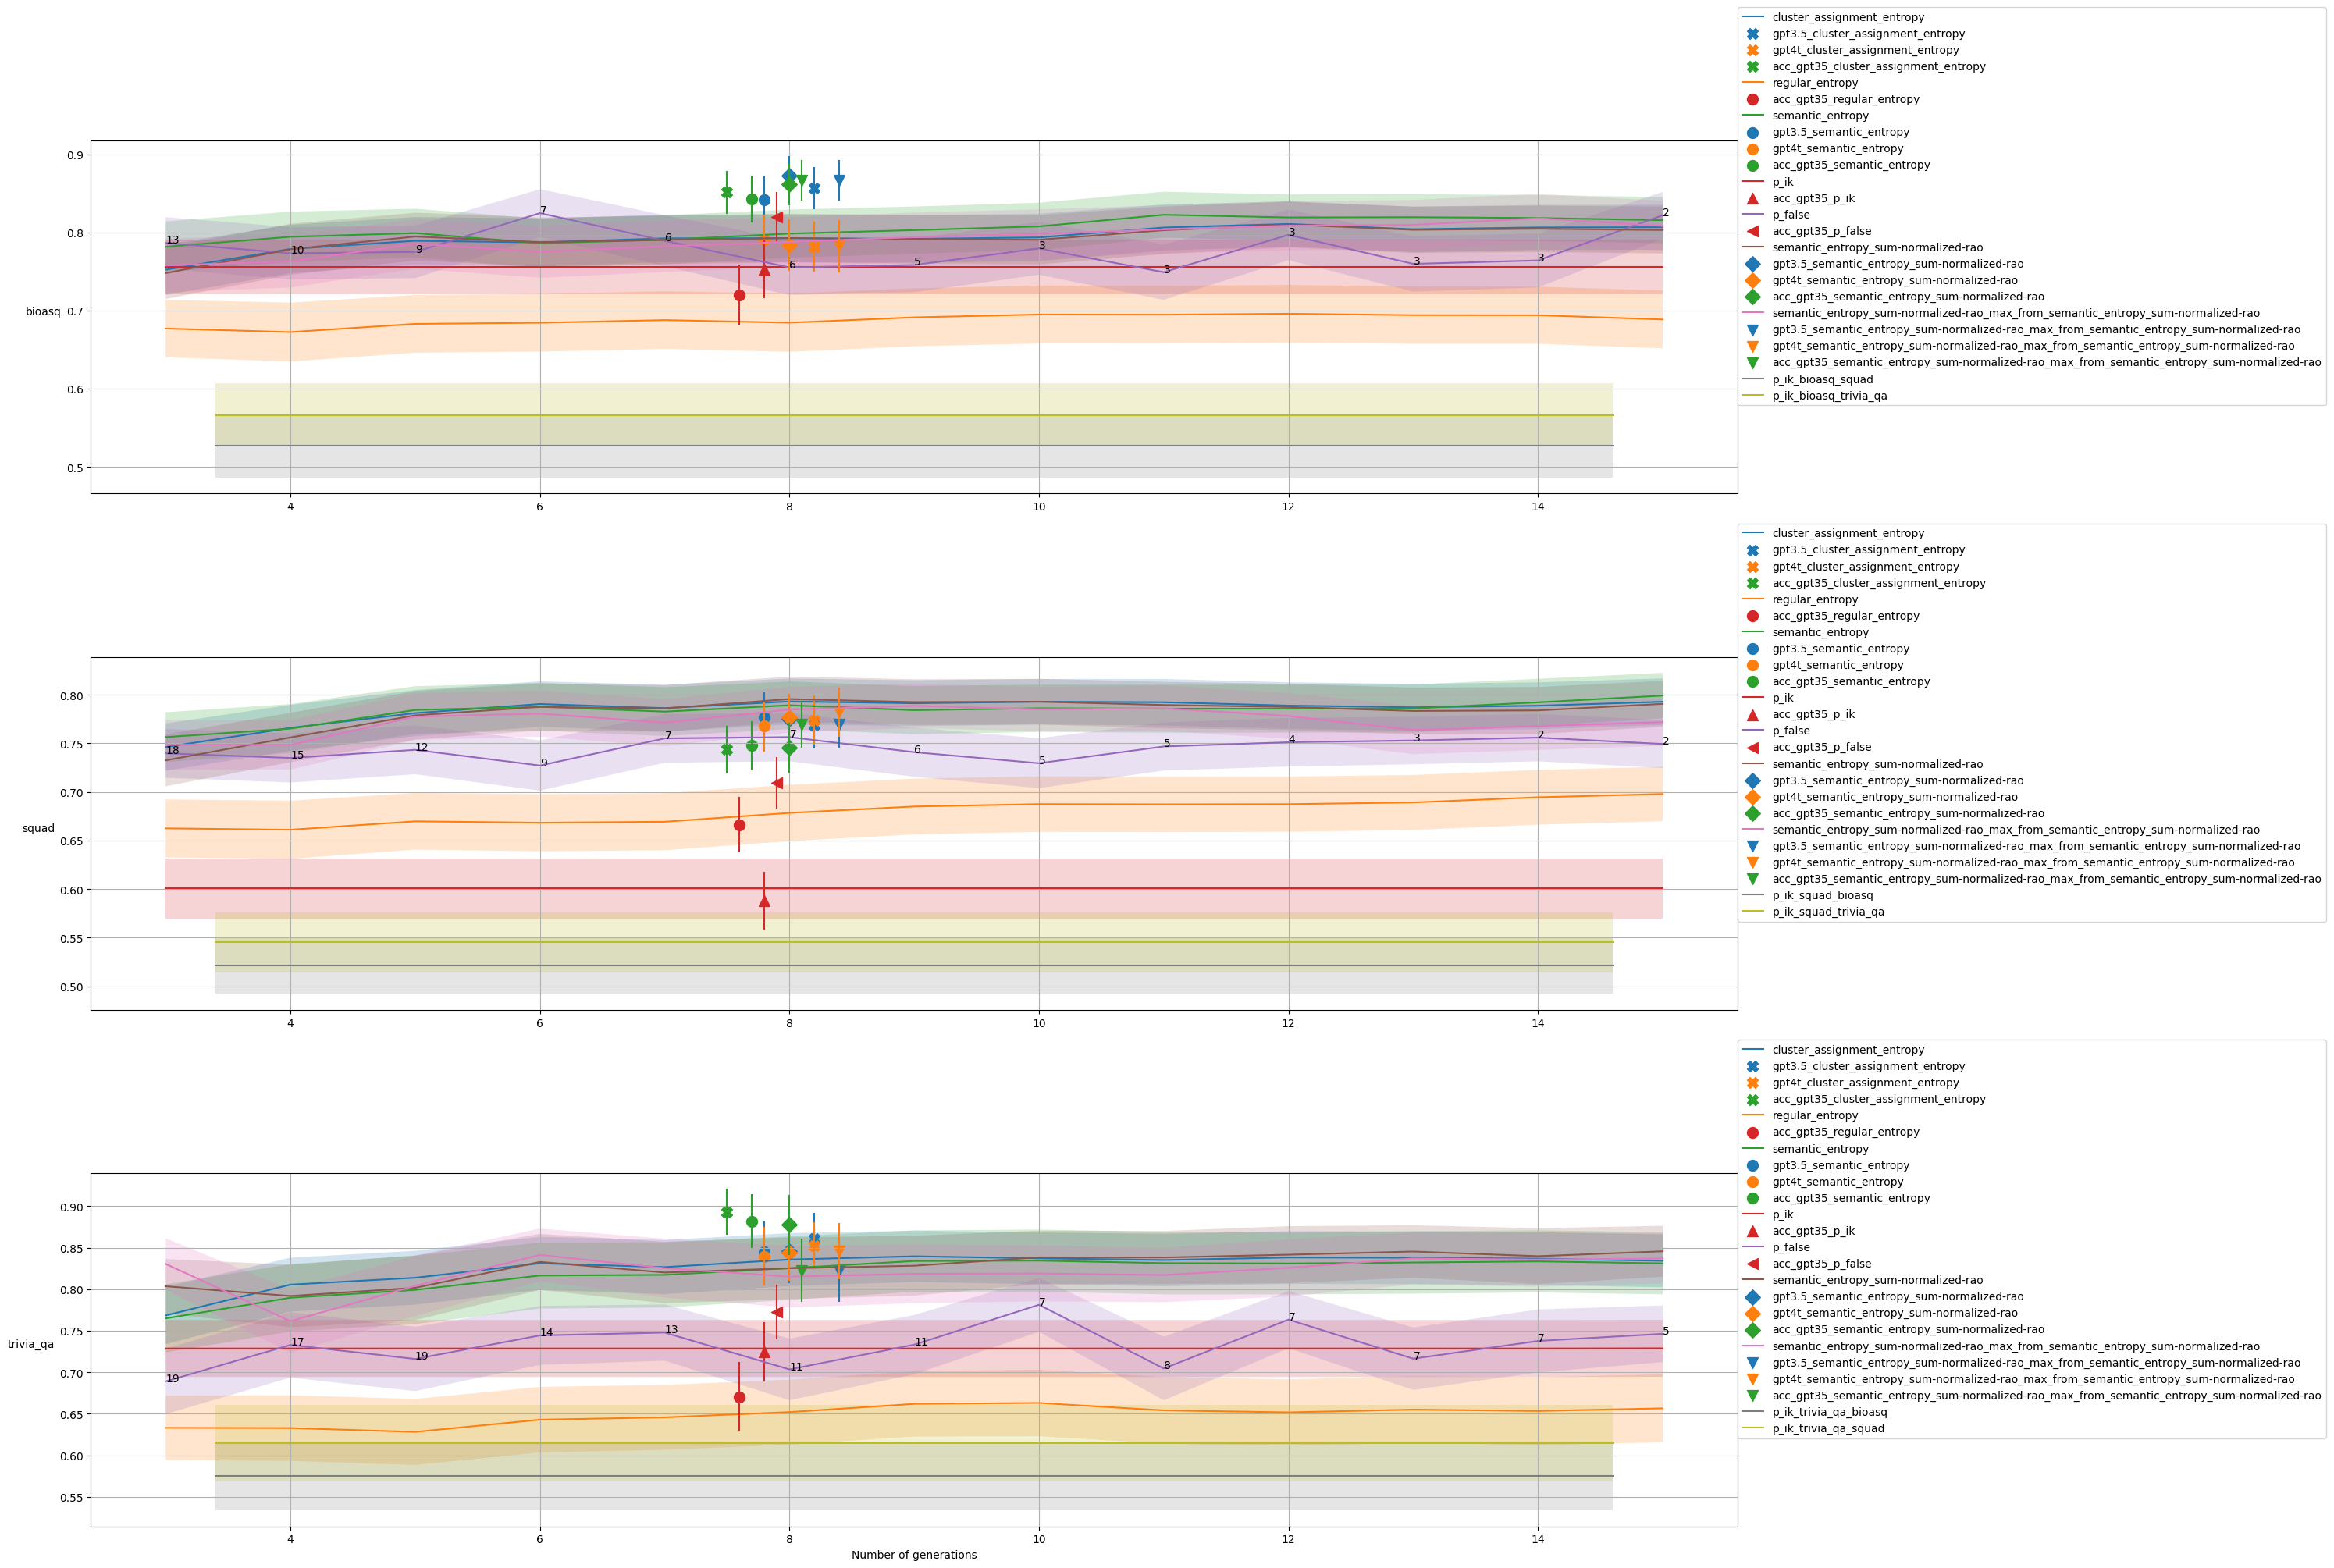

In [21]:
metric = 'AUROC'

df2 = deepcopy(all_runs)
df2 = df2[df2.metric == metric]
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']

fig, axes = plt.subplots(df2.dataset.nunique(), figsize=(30, 20))

if df2.dataset.nunique() == 1:
    axes = [axes]

methods = main_methods
# sem_methods = ['semantic_entropy', 'semantic_entropy_sum-normalized-rao']
sem_methods = ['semantic_entropy', 'semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']


for ax, (dataset, gdf) in  zip(axes, df2.groupby('dataset')):
    ax.set_ylabel(dataset, rotation=0, ha='right')
    ax.grid()
    k = 0
    for m, method in enumerate(methods):
        df3 = gdf[gdf.method == method]
        x, y, h, l = df3.num_generations.values, df3.means.values, df3.low.values, df3.high.values
        idxs = np.argsort(x)
        x, y, h, l = x[idxs], y[idxs], h[idxs], l[idxs]
        ax.plot(x, y, label=method)
        ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
        if method == 'p_false':
            ids = df3.wandb_id.values[idxs]
            if dataset == 'squad':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            elif dataset == 'trivia_qa':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 5})['value'] for wid in ids]
            elif dataset == 'bioasq':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            else:
                raise
            for xpos, ypos, text in zip(x, y, num_p_true):
                ax.text(xpos, ypos, text)
    
        if method in sem_methods:
            # skip for those methods b/c they do not depend on entailment
            tmp = gpt_all_runs.set_index('metric').loc[metric].set_index('dataset').loc[dataset].set_index('method').loc[method]
            jitter = (-1 + list(range(4))[sem_methods.index(method)])/5
            print(jitter)
            for i, (model, model_df) in enumerate(tmp.groupby('model')):
                x = gpt_configs[model_df.wandb_id.values[0]]['use_num_generations']['value']
                m, l, h = get_vals2(model_df.iloc[0])
                ax.scatter([x+jitter], [m], label=f'{model_df.model.values[0]}_{method}', c=f'C{i}', marker=['o', 'D', 'X', 'v'][sem_methods.index(method)], s=100)
                ax.plot([x+jitter, x+jitter], [l, h], c=f'C{i}')

            # # skip for those methods b/c they do not depend on entailment
            # tmp = acc_all_runs.set_index('metric').loc[metric].set_index('dataset').loc[dataset].set_index('method').loc[method]
            # jitter = (-1 + list(range(3))[sem_methods.index(method)])/5
            # x = acc_configs[tmp.wandb_id]['use_num_generations']['value']
            # m, l, h = get_vals2(tmp)
            # ax.scatter([x+jitter], [m], label=f'{tmp.model}_{method}', c=f'C{i+1}', marker=['o', 'D', 'X'][sem_methods.index(method)], s=100)
            # ax.plot([x+jitter, x+jitter], [l, h], c=f'C{i+1}')

        # skip for those methods b/c they do not depend on entailment
        tmp = acc_all_runs.set_index('metric').loc[metric].set_index('dataset').loc[dataset].set_index('method').loc[method]
        jitter = (-5 + list(range(10))[methods.index(method)])/10
        x = acc_configs[tmp.wandb_id]['use_num_generations']['value']
        m, l, h = get_vals2(tmp)
        ax.scatter([x+jitter], [m], label=f'{tmp.model}_{method}', c=f'C{i+1}' if method in sem_methods else f'C{i+2}', marker=['o', 'D', 'X', 'v'][sem_methods.index(method)] if method in sem_methods else ['.', 'o', 'v', '^', '<', '3', '4', '8', 's'][k], s=100)
        ax.plot([x+jitter, x+jitter], [l, h], c=f'C{i+1}' if method in sem_methods else f'C{i+2}')
        k += 1

    
    
    # plot p_ik_OOD
    xlims = ax.get_xlim()
    x = [xlims[0]+1, xlims[1]-1]
    for train_dataset, pik_tmp in pik_all_runs.set_index('metric').loc[metric].set_index('eval_dataset').loc[dataset].groupby('train_dataset'):
        m, l, h = get_vals2(pik_tmp.iloc[0])
        ax.plot(x, [m, m], label=f'p_ik_{dataset}_{train_dataset}')
        ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
    ax.set_xlim(*xlims)

    ax.legend(loc=(1, 0.25))

print("text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)")
plt.tight_layout()
axes[-1].set_xlabel('Number of generations')

print('note that p_false values for gpt35 acc are not representative!? --> ')

# Re-Run final gpt35 acc and entailment combo

In [22]:
# 169817 169818 169819
acc_reruns = {
    '': 'bioasq-acc_gpt35',
    '': 'squad-acc_gpt35',
    'lgurwdvq': 'trivia_qa-acc_gpt35',
}
acc_configs, acc_results = {}, {}

for wandb_id in acc_runs:
    acc_results[wandb_id], acc_configs[wandb_id] = restore_file(wandb_id)

acc_perfdf, acc_pdfs, acc_all_runs = get_perf_df(acc_runs, acc_results)
acc_all_runs['model'] = acc_all_runs.run.map(lambda x: x.split('-')[1])
acc_all_runs['dataset'] = acc_all_runs.run.map(lambda x: x.split('-')[0])

# this run uses gpt-35 to judge the accuracy, and gpt35 to compute entailment!

model,bioasq,squad,trivia_qa
dataset,,,
acc_gpt35,0.615,0.4325,0.8725


# Analyse precise numbers

In [23]:
tmp = all_runs.set_index('metric').loc['AUROC']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]

In [24]:
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high,num_generations
method,,,,
semantic_entropy_sum-normalized,0.807783,0.778127,0.837439,9.0
semantic_entropy,0.802153,0.770896,0.833410,9.0
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.801453,0.772075,0.830830,9.0
cluster_assignment_entropy,0.801333,0.772679,0.829988,9.0
semantic_entropy_sum-normalized-rao,0.800239,0.770389,0.830088,9.0
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.795260,0.765241,0.825280,9.0
semantic_entropy_max_from_semantic_entropy,0.794627,0.764178,0.825076,9.0
semantic_entropy_sum_sum-normalized_max_from_semantic_entropy_sum_sum-normalized,0.781388,0.750271,0.812504,9.0
semantic_entropy_sum_sum-normalized,0.775569,0.743603,0.807536,9.0


In [25]:
tmp[tmp.run.map(lambda x: '70b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high,num_generations
method,,,,


In [26]:
tmp[tmp.run.map(lambda x: '7b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high,num_generations
method,,,,


In [27]:
tmp.set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high,num_generations
method,,,,
semantic_entropy,0.802153,0.770896,0.833410,9.0
cluster_assignment_entropy,0.801333,0.772679,0.829988,9.0
semantic_entropy_sum-normalized-rao,0.800239,0.770389,0.830088,9.0
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.795260,0.765241,0.825280,9.0
p_false,0.752198,0.720538,0.783858,9.0
p_ik,0.695188,0.661857,0.728520,9.0
regular_entropy,0.672111,0.636898,0.707324,9.0


In [28]:
tmp[tmp.run.map(lambda x: '7b' in x)].set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

KeyError: "None of [Index(['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy',\n       'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao',\n       'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao'],\n      dtype='object', name='method')] are in the [index]"